### Projet_10  Réalisez une application de recommandation de contenu

In [ ]:
!pip install scikit-surprise pandas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.4/154.4 kB 5.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-surprise: filename=scikit_surprise-1.1.4-cp312-cp312-linux_x86_64.whl size=2554972 sha256=6fb8a418cbbf7670ccdebb483ffbb59e6a596072f4f02fb625adafd482b90443
  Stored in directory: /root/.cache/pip/wheels/75/fa/bc/739bc2cb1fbaab6061854e6cfbb81a0ae52c92a502a7fa454b
Successfully built scikit-surprise


In [ ]:
!pip install "numpy<2"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 94.7 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import pickle



import seaborn as sns
import os
import glob
from scipy.spatial import distance

interactions utilisateurs → articles cliqués

infos sur les articles

embeddings → représentation mathématique des articles

In [ ]:
# CHARGEMENT DES DONNÉES

df_art = pd.read_csv('articles_metadata.csv')
df_clicks = pd.read_csv('clicks_sample.csv')
with open('articles_embeddings.pickle', 'rb') as f:
   df_art_embed = pickle.load(f)



In [ ]:
df_art.head()

,article_id,category_id,created_at_ts,publisher_id,words_count
0,0,0,1513144419000,0,168
1,1,1,1405341936000,0,189
2,2,1,1408667706000,0,250
3,3,1,1408468313000,0,230
4,4,1,1407071171000,0,162


In [ ]:
df_clicks.head()

,user_id,session_id,session_start,session_size,click_article_id,click_timestamp,click_environment,click_deviceGroup,click_os,click_country,click_region,click_referrer_type
0,0,1506825423271737,1506825423000,2,157541,1506826828020,4,3,20,1,20,2
1,0,1506825423271737,1506825423000,2,68866,1506826858020,4,3,20,1,20,2
2,1,1506825426267738,1506825426000,2,235840,1506827017951,4,1,17,1,16,2
3,1,1506825426267738,1506825426000,2,96663,1506827047951,4,1,17,1,16,2
4,2,1506825435299739,1506825435000,2,119592,1506827090575,4,1,17,1,24,2


In [ ]:
df_art_embed

array([[-0.16118301, -0.95723313, -0.13794445, ..., -0.231686  ,
         0.5974159 ,  0.40962312],
       [-0.52321565, -0.974058  ,  0.73860806, ...,  0.18282819,
         0.39708954, -0.83436364],
       [-0.61961854, -0.9729604 , -0.20736018, ..., -0.44758022,
         0.8059317 , -0.28528407],
       ...,
       [-0.25139043, -0.9762427 ,  0.58609664, ..., -0.14372464,
         0.06809307, -0.7050104 ],
       [ 0.22434181, -0.92328775, -0.38174152, ...,  0.6871319 ,
        -0.5315117 ,  0.01072566],
       [-0.25713393, -0.9946313 ,  0.9837918 , ...,  0.98387307,
        -0.8381829 , -0.1792827 ]], dtype=float32)

In [ ]:
path = 'clicks/'
files = [os.path.join(path, file) for file in os.listdir(path) if file.endswith('.csv')]
data = [pd.read_csv(file) for file in files]
df_data = pd.concat(data, ignore_index=True)

### Analyse exploratoire des données

In [ ]:
df_data.head()

,user_id,session_id,session_start,session_size,click_article_id,click_timestamp,click_environment,click_deviceGroup,click_os,click_country,click_region,click_referrer_type
0,203311,1507376180417913,1507376180000,2,284985,1507376180582,4,3,20,1,17,6
1,203311,1507376180417913,1507376180000,2,351587,1507376210582,4,3,20,1,17,6
2,12672,1507376181265914,1507376181000,2,96755,1507376285792,4,1,17,1,13,2
3,12672,1507376181265914,1507376181000,2,141000,1507376315792,4,1,17,1,13,2
4,177791,1507376182105915,1507376182000,2,283238,1507376228759,4,1,17,1,25,2


In [ ]:
df_data.dtypes

,0
user_id,object
session_id,object
session_start,object
session_size,object
click_article_id,object
click_timestamp,object
click_environment,object
click_deviceGroup,object
click_os,object
click_country,object


In [ ]:
# compter le nombre de valeurs manquante
df_data.isnull().sum()

,0
user_id,0
session_id,0
session_start,0
session_size,0
click_article_id,0
click_timestamp,0
click_environment,0
click_deviceGroup,0
click_os,0
click_country,0


In [ ]:
# Statistiques descriptives
df_data.describe(include='all')

,user_id,session_id,session_start,session_size,click_article_id,click_timestamp,click_environment,click_deviceGroup,click_os,click_country,click_region,click_referrer_type
count,2988181,2988181,2988181,2988181,2988181,2988181,2988181,2988181,2988181,2988181,2988181,2988181
unique,322897,1048594,646874,72,46033,2983198,3,5,8,11,28,7
top,5890,1507563657895091,1507563657000,2,160974,1507905588690,4,1,17,1,25,2
freq,1232,124,127,1260372,37213,3,2904478,1823162,1738138,2852406,804985,1602601


In [ ]:
# compter le nombre de valeurs uniques
df_data.nunique()

,0
user_id,322897
session_id,1048594
session_start,646874
session_size,72
click_article_id,46033
click_timestamp,2983198
click_environment,3
click_deviceGroup,5
click_os,8
click_country,11


In [ ]:
# Affiche les colonnes catégorielles et la distribution des valeurs dans chacune
for col in df_data.select_dtypes(include='object'):
    display(df_data[col].value_counts())


,count
user_id,
5890,1232
73574,939
15867,900
80350,783
15275,746
...,...
273073,2
273071,2
273070,2


,count
session_id,
1507563657895091,124
1507896573228093,107
1507133567968022,106
1507309773225261,98
1508112331270612,94
...,...
1507008676102417,2
1507008678207418,2
1507008704104422,2


,count
session_start,
1507563657000,127
1507896573000,112
1507133567000,108
1507309773000,98
1507647366000,97
...,...
1507008591000,2
1507008593000,2
1507008596000,2


,count
session_size,
2,1260372
3,670185
4,374240
5,220105
6,135762
...,...
62,62
60,60
58,58


,count
click_article_id,
160974,37213
272143,28943
336221,23851
234698,23499
123909,23122
...,...
168361,1
111342,1
36574,1


...

,count
click_deviceGroup,
1,1823162
3,1047086
4,117640
5,283
2,10


,count
click_os,
17,1738138
2,788699
20,369586
12,60096
13,23711
19,6384
5,1513
3,54


,count
click_country,
1,2852406
10,61377
11,29999
8,9556
6,7256
9,6746
2,6101
3,4540
5,3498


,count
click_region,
25,804985
21,464230
13,320957
8,179339
16,164884
28,135793
24,130537
20,120884
5,96979


,count
click_referrer_type,
2,1602601
1,1194321
5,80766
7,69798
6,20455
4,19820
3,420


In [ ]:
df_art.head()

,article_id,category_id,created_at_ts,publisher_id,words_count
0,0,0,1513144419000,0,168
1,1,1,1405341936000,0,189
2,2,1,1408667706000,0,250
3,3,1,1408468313000,0,230
4,4,1,1407071171000,0,162


In [ ]:
df_art.dtypes

,0
article_id,int64
category_id,int64
created_at_ts,int64
publisher_id,int64
words_count,int64


In [ ]:
df_art.isnull().sum()

,0
article_id,0
category_id,0
created_at_ts,0
publisher_id,0
words_count,0


In [ ]:
df_art.describe(include='all')

,article_id,category_id,created_at_ts,publisher_id,words_count
count,364047.000000,364047.000000,3.640470e+05,364047.0,364047.000000
mean,182023.000000,283.108239,1.474070e+12,0.0,190.897727
std,105091.461061,136.723470,4.293038e+10,0.0,59.502766
min,0.000000,0.000000,1.159356e+12,0.0,0.000000
25%,91011.500000,199.000000,1.444925e+12,0.0,159.000000
50%,182023.000000,301.000000,1.489422e+12,0.0,186.000000
75%,273034.500000,399.000000,1.509891e+12,0.0,218.000000
max,364046.000000,460.000000,1.520943e+12,0.0,6690.000000


In [ ]:
df_art.nunique()

,0
article_id,364047
category_id,461
created_at_ts,359552
publisher_id,1
words_count,866


In [ ]:
# les colonnes catégorielles et afficher la distribution des valeurs dans chacune
for col in df_art.select_dtypes(include='int64'):
    display(df_art[col].value_counts())

,count
article_id,
364046,1
0,1
1,1
2,1
3,1
...,...
19,1
18,1
17,1


,count
category_id,
281,12817
375,10005
399,9049
412,8648
431,7759
...,...
35,1
5,1
427,1


,count
created_at_ts,
1425081603000,11
1470290406000,10
1509868802000,8
1478066402000,8
1506844802000,7
...,...
1516380968000,1
1511981076000,1
1518192389000,1


,count
publisher_id,
0,364047


,count
words_count,
176,3485
182,3480
179,3463
178,3458
174,3456
...,...
680,1
629,1
671,1


In [ ]:
# fusion 2 DataFrames
df_fus = df_data.merge(df_art, left_on='click_article_id', right_on='article_id')
display(df_fus)

,user_id,session_id,session_start,session_size,click_article_id,click_timestamp,click_environment,click_deviceGroup,click_os,click_country,click_region,click_referrer_type,article_id,category_id,created_at_ts,publisher_id,words_count
0,203311,1507376180417913,1507376180000,2,284985,1507376180582,4,3,20,1,17,6,284985,412,1507356061000,0,184
1,203311,1507376180417913,1507376180000,2,351587,1507376210582,4,3,20,1,17,6,351587,442,1507309624000,0,152
2,12672,1507376181265914,1507376181000,2,96755,1507376285792,4,1,17,1,13,2,96755,209,1507326628000,0,211
3,12672,1507376181265914,1507376181000,2,141000,1507376315792,4,1,17,1,13,2,141000,265,1507366509000,0,150
4,177791,1507376182105915,1507376182000,2,283238,1507376228759,4,1,17,1,25,2,283238,412,1507313473000,0,186
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2988176,13950,1507008945409469,1507008945000,3,324823,1507008984812,2,3,20,11,28,2,324823,434,1506972472000,0,202
2988177,13950,1507008945409469,1507008945000,3,285648,1507009127036,2,3,20,11,28,1,285648,412,1506986098000,0,305
2988178,13950,1507008945409469,1507008945000,3,337890,1507009157036,2,3,20,11,28,1,337890,437,1506964227000,0,206
2988179,117542,1507008957412470,1507008957000,2,64329,1507008996618,4,3,2,1,21,2,64329,134,1506970055000,0,199


### Fonction d'identification des articles les plus populaires

In [ ]:
def popular2(df):
    return df['article_id'].value_counts().reset_index()

In [ ]:
art_pop2 = popular2(df_fus)
art_pop2[:10]

,article_id,count
0,160974,37213
1,272143,28943
2,336221,23851
3,234698,23499
4,123909,23122
5,336223,21855
6,96210,21577
7,162655,21062
8,183176,20303
9,168623,19526


In [ ]:

def interaction(df, n_users=100, n_articles=100, save_path='top_users.pkl', display_matrix=True):
    """
    Crée une matrice d'interaction utilisateur–article.

    Parameters:
    - df (DataFrame): Données contenant au moins 'user_id' et 'click_article_id'
    - n_users (int): Nombre de top utilisateurs à garder
    - n_articles (int): Nombre de top articles à garder
    - save_path (str): Chemin pour sauvegarder les top utilisateurs
    - display_matrix (bool): Afficher ou non la matrice

    Returns:
    - DataFrame: matrice utilisateur–article
    """

    # 1. Top utilisateurs
    top_users = df['user_id'].value_counts().head(n_users).index

    # 2. Sauvegarde
    if save_path:
        with open(save_path, 'wb') as f:
            pickle.dump(top_users, f)

    # 3. Top articles
    top_articles = df['click_article_id'].value_counts().head(n_articles).index

    # 4. Filtrage
    filtered_df = df[
        df['user_id'].isin(top_users) &
        df['click_article_id'].isin(top_articles)
    ]

    # 5. Matrice d'interaction
    user_article = filtered_df.pivot_table(
        index='user_id',
        columns='click_article_id',
        aggfunc='size',
        fill_value=0
    )

    # 6. Réindexation (important)
    user_article = user_article.reindex(
        index=top_users,
        columns=top_articles,
        fill_value=0
    )

    # 7. Affichage optionnel
    if display_matrix:
        try:
            from IPython.display import display
            display(user_article)
        except ImportError:
            print(user_article)

    return user_article

In [ ]:
artUser = interaction(df_fus)


click_article_id,160974,272143,336221,234698,123909,336223,96210,162655,183176,168623,...,160132,96755,237524,161801,157478,119534,284844,315105,141004,16129
user_id,,,,,,,,,,,,,,,,,,,,,
5890,0,1,0,1,1,0,0,0,0,0,...,0,0,1,0,2,0,0,0,0,0
73574,1,0,1,1,1,2,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0
15867,3,0,1,3,9,0,1,3,1,2,...,0,0,3,1,1,1,0,0,2,0
80350,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
15275,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1819,1,1,0,0,0,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
13407,0,0,0,0,1,0,0,0,0,1,...,0,0,0,0,0,2,0,0,0,0
22301,1,0,0,1,0,1,1,1,1,0,...,0,1,0,0,1,0,0,1,0,1


In [ ]:
artUser.to_csv('art_user100.csv', index=False)
df_art_user100 = pd.read_csv('art_user100.csv')
df_art_user100

,160974,272143,336221,234698,123909,336223,96210,162655,183176,168623,...,160132,96755,237524,161801,157478,119534,284844,315105,141004,16129
0,0,1,0,1,1,0,0,0,0,0,...,0,0,1,0,2,0,0,0,0,0
1,1,0,1,1,1,2,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0
2,3,0,1,3,9,0,1,3,1,2,...,0,0,3,1,1,1,0,0,2,0
3,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,1,1,0,0,0,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
96,0,0,0,0,1,0,0,0,0,1,...,0,0,0,0,0,2,0,0,0,0
97,1,0,0,1,0,1,1,1,1,0,...,0,1,0,0,1,0,0,1,0,1
98,1,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
df_user100 = pd.read_csv('art_user100.csv')

In [ ]:
df_fus

,user_id,session_id,session_start,session_size,click_article_id,click_timestamp,click_environment,click_deviceGroup,click_os,click_country,click_region,click_referrer_type,article_id,category_id,created_at_ts,publisher_id,words_count
0,203311,1507376180417913,1507376180000,2,284985,1507376180582,4,3,20,1,17,6,284985,412,1507356061000,0,184
1,203311,1507376180417913,1507376180000,2,351587,1507376210582,4,3,20,1,17,6,351587,442,1507309624000,0,152
2,12672,1507376181265914,1507376181000,2,96755,1507376285792,4,1,17,1,13,2,96755,209,1507326628000,0,211
3,12672,1507376181265914,1507376181000,2,141000,1507376315792,4,1,17,1,13,2,141000,265,1507366509000,0,150
4,177791,1507376182105915,1507376182000,2,283238,1507376228759,4,1,17,1,25,2,283238,412,1507313473000,0,186
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2988176,13950,1507008945409469,1507008945000,3,324823,1507008984812,2,3,20,11,28,2,324823,434,1506972472000,0,202
2988177,13950,1507008945409469,1507008945000,3,285648,1507009127036,2,3,20,11,28,1,285648,412,1506986098000,0,305
2988178,13950,1507008945409469,1507008945000,3,337890,1507009157036,2,3,20,11,28,1,337890,437,1506964227000,0,206
2988179,117542,1507008957412470,1507008957000,2,64329,1507008996618,4,3,2,1,21,2,64329,134,1506970055000,0,199


In [ ]:
import pandas as pd

# 1. Charger seulement 100 lignes
df_user = df_fus.head(100)

# 2. Garder uniquement les colonnes voulues
colonnes = ["user_id", "article_id"]  # adapte ici
df_user = df_user[colonnes]

df_user

,user_id,article_id
0,203311,284985
1,203311,351587
2,12672,96755
3,12672,141000
4,177791,283238
...,...,...
95,77887,235804
96,52627,160158
97,52627,235689
98,52627,96755


In [ ]:
df_user.to_csv("users_100.csv", index=False)

# Création d'un rating implicite

In [ ]:
def rating(df):
    """
    Calcule un score de popularité normalisée par utilisateur et article.
    """

    # 1. Nombre total de clics par utilisateur
    user_total_clicks = df.groupby('user_id').size()

    # 2. Nombre de clics par (user, article)
    article_user_clicks = (
        df.groupby(['user_id', 'article_id'])
        .size()
        .rename('article_user_clicks')
        .reset_index()
    )

    # 3. Ajouter total clics utilisateur (plus efficace avec map)
    article_user_clicks['user_total_clicks'] = (
        article_user_clicks['user_id'].map(user_total_clicks)
    )

    # 4. Score normalisé
    article_user_clicks['normalized_popularity'] = (
        article_user_clicks['article_user_clicks'] /
        article_user_clicks['user_total_clicks']
    )

    # 5. Tri (plus pertinent)
    sorted_articles = article_user_clicks.sort_values(
        by='normalized_popularity',
        ascending=False
    )

    return sorted_articles

In [ ]:
articles_trie = rating(df_fus)
articles_trie

,user_id,article_id,article_user_clicks,user_total_clicks,normalized_popularity
2950670,322878,224730,1,2,0.500000
2950681,322883,36162,1,2,0.500000
2950709,322896,157507,1,2,0.500000
2950665,322876,285300,1,2,0.500000
2950674,322880,50644,1,2,0.500000
...,...,...,...,...,...
134667,5890,285212,1,1232,0.000812
134668,5890,285635,1,1232,0.000812
134669,5890,285663,1,1232,0.000812
134670,5890,285675,1,1232,0.000812


In [ ]:
with open("ratings.pkl", "wb") as f:
    pickle.dump(articles_trie, f)

In [ ]:
with open("ratings.pkl", "rb") as file:
    articles_trie = pickle.load(file)

# 1- Content-Based Filtering Model (Modèle de filtrage basé sur le contenu)


In [ ]:
# un moteur de recommandation basé sur la similarité des contenus

# -----------------------------
# Popularité (fallback)
# -----------------------------
def popular(df, n=10):
    return (
        df['article_id']
        .value_counts()
        .index
        .tolist()[:n]
    )


# -----------------------------
# Embedding utilisateur pondéré
# -----------------------------
def plongements_moyens_ponderes(user_articles, user_click_counts, articles_emb, article_id_to_index):
    total_weight = sum(user_click_counts)
    weighted_embedding = np.zeros(articles_emb.shape[1])

    for article_id, click_count in zip(user_articles, user_click_counts):
        if article_id in article_id_to_index:
            idx = article_id_to_index[article_id]
            weighted_embedding += articles_emb[idx] * (click_count / total_weight)

    return weighted_embedding


# -----------------------------
# Recommandation (mapping auto)
# -----------------------------
def articles_recomm(userId, n, articles_emb, df_clicks):
    """
    Recommande n articles pour un utilisateur.
    """

    # Vérification colonnes
    required_cols = ['user_id', 'article_id', 'article_user_clicks']
    for col in required_cols:
        if col not in df_clicks.columns:
            raise ValueError(f"Colonne manquante: {col}")

    # -----------------------------
    # 🔥 Création automatique du mapping
    # -----------------------------
    article_ids = df_clicks['article_id'].unique()
    article_id_to_index = {aid: i for i, aid in enumerate(article_ids)}

    # ⚠️ Vérification cohérence embeddings
    if len(article_ids) > len(articles_emb):
        raise ValueError("Mismatch entre nombre d'articles et embeddings")

    # -----------------------------
    # Données utilisateur
    # -----------------------------
    user_data = df_clicks[df_clicks['user_id'] == userId]

    user_articles = user_data['article_id'].tolist()
    user_click_counts = user_data['article_user_clicks'].tolist()

    # -----------------------------
    # Cold start
    # -----------------------------
    if len(user_articles) == 0:
        print(f"User {userId} n'a aucun historique → fallback popularité")
        return [(art, None) for art in popular(df_clicks, n)]

    # -----------------------------
    # Profil utilisateur
    # -----------------------------
    user_embedding = plongements_moyens_ponderes(
        user_articles,
        user_click_counts,
        articles_emb,
        article_id_to_index
    )

    # -----------------------------
    # Articles non lus
    # -----------------------------
    all_articles = set(article_ids)
    unread_articles = list(all_articles - set(user_articles))

    unread_indices = [article_id_to_index[a] for a in unread_articles if a in article_id_to_index]

    # -----------------------------
    # Similarité cosinus
    # -----------------------------
    cos_distance = distance.cdist(
        [user_embedding],
        articles_emb[unread_indices],
        metric='cosine'
    )[0]

    similarity_scores = 1 - cos_distance

    # -----------------------------
    # Top N
    # -----------------------------
    top_indices = np.argsort(similarity_scores)[::-1][:n]

    notesArtRecomm = [
        (unread_articles[i], similarity_scores[i])
        for i in top_indices
    ]

    return notesArtRecomm

In [ ]:
scores_articles = articles_recomm(16280, 5, df_art_embed, articles_trie)

In [ ]:
scores_articles

[(206402, 0.8758801019668996),
 (300472, 0.8630746307815832),
 (38261, 0.8627095260201582),
 (62675, 0.8538117200846851),
 (41595, 0.853711717504223)]

In [ ]:
for article_id, score in scores_articles:
    print(f"Article_recom : {article_id}, Score similarité : {score} ")

Article_recom : 206402, Score similarité : 0.8758801019668996 
Article_recom : 300472, Score similarité : 0.8630746307815832 
Article_recom : 38261, Score similarité : 0.8627095260201582 
Article_recom : 62675, Score similarité : 0.8538117200846851 
Article_recom : 41595, Score similarité : 0.853711717504223 


## Réduction de la dimension des l'embeddings

In [ ]:
from sklearn.decomposition import PCA

In [ ]:
def variance(articles_embedding, n_components=None, threshold=0.95):
    from sklearn.decomposition import PCA
    import numpy as np
    import matplotlib.pyplot as plt

    pca = PCA(n_components=n_components)
    pca.fit(articles_embedding)

    rapVarianceExplk = pca.explained_variance_ratio_
    ecartExplCumul  = np.cumsum(rapVarianceExplk)

    # Trouver le nombre optimal de composants
    n_optimal = np.argmax(ecartExplCumul >= threshold) + 1
    print(f"{n_optimal} components explain {threshold*100:.1f}% of the variance")

    # Plot
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, len(ecartExplCumul) + 1), ecartExplCumul, marker='o')
    plt.axhline(y=threshold, linestyle='--')
    plt.xlabel('Nombre de composants')
    plt.ylabel('Variance expliquée cumulée')
    plt.title('Variance expliquée cumulée en fonction du nombre de composantes')
    plt.grid(True)
    plt.show()

    return rapVarianceExplk, ecartExplCumul

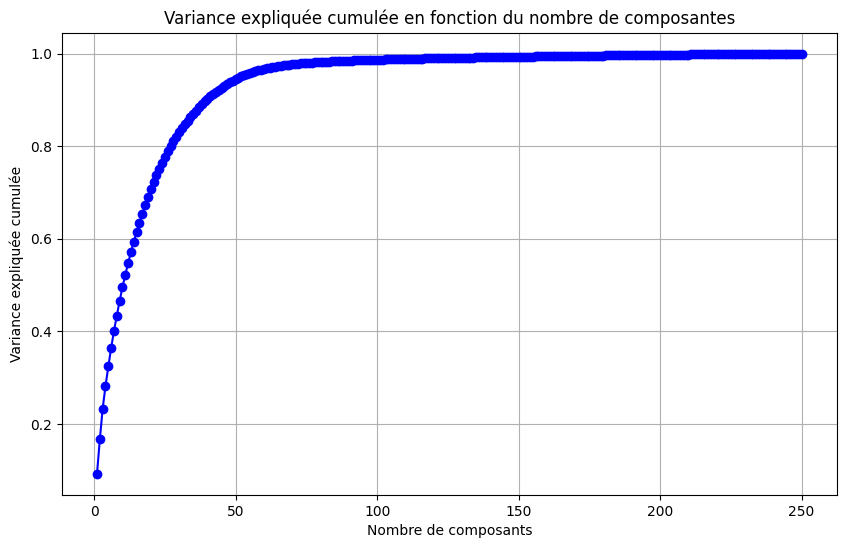

In [ ]:
def variance(artEmbe):
    pca = PCA()
    pca.fit(artEmbe)

    # Plot explained variance ratio
    rapVarianceExplk = pca.explained_variance_ratio_
    ecartExplCumul = np.cumsum(rapVarianceExplk)

    # Plot the explained variance
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, len(ecartExplCumul) + 1), ecartExplCumul, marker='o', linestyle='-', color='b')
    plt.title('Variance expliquée cumulée en fonction du nombre de composantes')
    plt.xlabel('Nombre de composants')
    plt.ylabel('Variance expliquée cumulée')
    plt.grid(True)
    plt.show()

variance(df_art_embed)

In [ ]:
idsArts = list(range(df_art_embed.shape[0]))
len(idsArts)
with open('all_article_ids.pkl', 'wb') as f:
    pickle.dump(idsArts, f)

print("La liste a été enregistrée avec succès dans 'idsArts.pkl'.")

La liste a été enregistrée avec succès dans 'idsArts.pkl'.


In [ ]:
def make_pca(articles_embedding, n_components=100):
    pca = PCA(n_components=n_components)
    articles_embeddings_pca = pca.fit_transform(articles_embedding)
    print(pca.explained_variance_ratio_.sum())
    return articles_embeddings_pca

articles_embeddings_pca = make_pca(df_art_embed)
with open("articles_embeddings_pca.pkl", "wb") as f:
    pickle.dump(articles_embeddings_pca, f)

0.9871515


In [ ]:
# Affiche 10 articles les plus similaires à l’article 169174
scoreArtrecomm = articles_recomm(169174, 5,  df_art_embed, articles_trie)
for article_id, score in scoreArtrecomm:
    print(f"Article : {article_id}, score de similarité : {score} ")

Article : 285095, score de similarité : 0.9229325385733279 
Article : 299170, score de similarité : 0.9191847271014204 
Article : 160129, score de similarité : 0.9088606212716285 
Article : 217595, score de similarité : 0.9081469818538989 
Article : 139345, score de similarité : 0.9070593851179601 



# 2- Collaborative Filtering Model  (Modèle de filtrage collaboratif)

### Approche basée sur un modèle. (SVD++)

In [ ]:
from scipy.spatial import distance
from random import choice, randint
from surprise import KNNWithMeans, KNNBasic, Reader, Dataset, SVD, accuracy, SVDpp
from surprise.model_selection import GridSearchCV, train_test_split, cross_validate
from sklearn.model_selection import train_test_split as skl_train_test_split
from sklearn.preprocessing import MinMaxScaler

In [ ]:
articles_trie[['user_id', 'article_id', 'normalized_popularity']]

,user_id,article_id,normalized_popularity
2950670,322878,224730,0.500000
2950681,322883,36162,0.500000
2950709,322896,157507,0.500000
2950665,322876,285300,0.500000
2950674,322880,50644,0.500000
...,...,...,...
134667,5890,285212,0.000812
134668,5890,285635,0.000812
134669,5890,285663,0.000812
134670,5890,285675,0.000812


In [ ]:
def scale_rating(df, feature_range):
    df = df[['user_id', 'article_id', 'normalized_popularity']]
    X_train, X_test = skl_train_test_split(df, test_size=0.25, random_state=0)
    scaler = MinMaxScaler(feature_range=feature_range)
    X_train['normalized_popularity'] = scaler.fit_transform(X_train[['normalized_popularity']])
    X_test['normalized_popularity'] = scaler.transform(X_test[['normalized_popularity']])
    X = pd.concat([X_test, X_train], axis=0).reset_index(drop=True)
    return X
X = scale_rating(articles_trie, (0,1))

In [ ]:
X.sort_values(by='normalized_popularity', ascending=False)

,user_id,article_id,normalized_popularity
733051,269955,78967,1.0
732917,19863,118180,1.0
2120788,321313,331116,1.0
732914,299427,313920,1.0
2663859,319227,190419,1.0
...,...,...,...
1011859,5890,58689,0.0
1437016,5890,207731,0.0
1136112,5890,205901,0.0
2630853,5890,57668,0.0


In [ ]:
reader = Reader(rating_scale=(0,1))
data = Dataset.load_from_df(X[['user_id', 'article_id', 'normalized_popularity']], reader)
trainset, testset = train_test_split(data, test_size=0.25, random_state=0)

In [ ]:
# rmse : Compute RMSE (Root Mean Squared Error)
algo = SVDpp()
algo.fit(trainset)
pred  = algo.test(testset)
accuracy.rmse(pred)

RMSE: 0.3575


0.35751610085242524

In [ ]:
# enregistrer l’objet algo dans un fichier
with open("svd_algo.pkl", "wb") as f:
    pickle.dump(algo, f)

In [ ]:
# transformer une liste de prédictions en recommandations “Top N par utilisateur”
# extraire les meilleures recommandations par utilisateur à partir des prédictions d’un modèle SVD

from collections import defaultdict

def best_recomm(predictions, n=5):
    """
    Retourne les N meilleures recommandations par utilisateur.

    Parameters:
    - predictions : liste de tuples (uid, iid, true_r, est, details)
    - n : nombre de recommandations à garder

    Returns:
    - dict : {user_id: [(item_id, score), ...]}
    """

    top_n = defaultdict(list)

    # 1. Regrouper les prédictions par utilisateur
    for uid, iid, _, est, _ in predictions:
        top_n[uid].append((iid, est))

    # 2. Trier et garder les N meilleurs
    for uid in top_n:
        top_n[uid] = sorted(
            top_n[uid],
            key=lambda x: x[1],
            reverse=True
        )[:n]

    return dict(top_n)

In [ ]:
Best_svd = best_recomm(pred, n=5)
Best_svd

{267873: [(156052, 0.5637833228534582)],
 76219: [(354086, 0.5362547575877128),
  (313995, 0.2526631351384105),
  (307856, 0.1876845902199065),
  (208077, 0.17728164045352388)],
 113287: [(166581, 0.8613657270364626)],
 51001: [(272660, 0.7139176036221145),
  (272143, 0.7070544533012494),
  (324823, 0.5064992576441197),
  (96029, 0.24789696309519604)],
 127776: [(64352, 0.40820934151462335), (172253, 0.34928635244708633)],
 161828: [(235854, 0.5277766233903525),
  (124350, 0.4846337031156735),
  (58580, 0.47586688747261674),
  (161506, 0.4458305770798467),
  (161801, 0.4436494895702912)],
 91545: [(284547, 0.4960206774314989),
  (175040, 0.489910443010743),
  (284096, 0.4386076971160656),
  (207603, 0.3785217962663388),
  (272514, 0.15208126402232194)],
 191832: [(169146, 0.3690283960112908), (169136, 0.32547154107183335)],
 35167: [(160417, 0.5915789323014368),
  (336245, 0.5822339364991529),
  (158536, 0.5790713839723997),
  (108856, 0.4917955408669277),
  (235132, 0.4909291108499398

In [ ]:
# enregistrement
with open("Best_svd.txt", "wb") as file:
    pickle.dump(Best_svd, file)

In [ ]:
def svd_function(user_id, all_article_ids, algo, n=10):

    predictions = []

    for article_id in all_article_ids:
        pred = algo.predict(uid=user_id, iid=article_id)
        predictions.append((article_id, pred.est))

    return sorted(predictions, key=lambda x: x[1], reverse=True)[:n]

In [ ]:
articless = range(df_art.article_id.max())
predic_util = svd_function(169174, articless, algo)
predic_util

[(160974, 0.738571466447017),
 (162655, 0.7372540225300267),
 (234698, 0.7336283038314647),
 (183176, 0.7313897517200553),
 (123909, 0.7276398806595414),
 (168623, 0.7263186441458064),
 (331116, 0.7254592819270553),
 (64329, 0.7042189399887968),
 (96210, 0.7001992617383077),
 (160417, 0.6997342806785597)]

### 3 - Modèle Hybride (SVD++ et CBF)

In [ ]:
with open("svd_algo.pkl", "rb") as file:
    algo = pickle.load(file)

In [ ]:
def recomHybrid(user_id, w, articles_emb, df_clicks, all_article_ids, algo, n):
    """
    Retourne une liste d'articles recommandés basée sur une combinaison linéaire des scores
    de similarité de CBF et SVD++.
    """

    # Obtenir les recommandations de CBF
    cbf_recommendations = articles_recomm(user_id, n, articles_emb, df_clicks)
    print(f"CBF recommandations : \n {cbf_recommendations}")

    # Obtenir les recommandations de SVD++
    svd_recommendations = svd_function(user_id, all_article_ids, algo, n)
    print(f"SVD++ recommandations : \n {svd_recommendations}")

    # Créer un dictionnaire pour stocker les scores combinés
    combined_scores = {}
    if cbf_recommendations:
        for article_id, score in cbf_recommendations:
            combined_scores[article_id] = w * score

    for article_id, score in svd_recommendations:
        if article_id in combined_scores:
            combined_scores[article_id] += (1 - w) * score
        else:
            combined_scores[article_id] = (1 - w) * score

    # Trier les articles par score combiné de manière décroissante
    recommended_articles = sorted(combined_scores.items(), key=lambda x: x[1], reverse=True)
    top_recommended = recommended_articles[:n]
    print(f"Hybrid recommandations : \n {top_recommended}")

    return top_recommended

# Exemple d'utilisation
all_article_ids = list(range(df_art.article_id.nunique()))


In [ ]:
ArtRecom = recomHybrid(272143, 0.5, df_art_embed, articles_trie, all_article_ids, algo, 10)

CBF recommandations : 
 [(195009, 0.8976089517002196), (34703, 0.8970421224637908), (87193, 0.8965295261389616), (285095, 0.895093062086729), (106690, 0.8907469188557682), (124350, 0.889930993879959), (338405, 0.889072112316829), (139345, 0.8882269129596142), (39791, 0.8857234608724395), (57887, 0.884026936975703)]
SVD++ recommandations : 
 [(234698, 0.8371408023369336), (183176, 0.8299202174981833), (162655, 0.8282256209003723), (331116, 0.8216544298211458), (64329, 0.8200546937197295), (123909, 0.818138015991505), (168623, 0.8148896357628397), (336221, 0.8113599234349531), (336223, 0.8065033881856122), (96210, 0.804518900555403)]
Hybrid recommandations : 
 [(195009, 0.4488044758501098), (34703, 0.4485210612318954), (87193, 0.4482647630694808), (285095, 0.4475465310433645), (106690, 0.4453734594278841), (124350, 0.4449654969399795), (338405, 0.4445360561584145), (139345, 0.4441134564798071), (39791, 0.44286173043621974), (57887, 0.4420134684878515)]


In [ ]:
ArtRecom = recomHybrid(57966, 0.5, df_art_embed, articles_trie, all_article_ids, algo, 10)

CBF recommandations : 
 [(226681, 0.9181419684776361), (159019, 0.8944295698272459), (207994, 0.8873135714603161), (97108, 0.8786426126842601), (194966, 0.8761507479109543), (58095, 0.872802178235061), (305025, 0.8727716674738399), (205982, 0.8699951673189574), (61259, 0.8698427410399934), (156878, 0.86811056783643)]
SVD++ recommandations : 
 [(234698, 0.9496397826440522), (162655, 0.92984748603745), (183176, 0.9288857345158397), (64329, 0.9263214055643534), (235616, 0.9193026660653209), (336221, 0.9185959293514042), (331116, 0.9183158557168747), (168623, 0.9166239465028835), (123909, 0.9165104023598349), (96210, 0.9085986163759167)]
Hybrid recommandations : 
 [(234698, 0.4748198913220261), (162655, 0.464923743018725), (183176, 0.46444286725791983), (64329, 0.4631607027821767), (235616, 0.4596513330326604), (336221, 0.4592979646757021), (331116, 0.45915792785843734), (226681, 0.45907098423881804), (168623, 0.45831197325144174), (123909, 0.45825520117991747)]


## 4 - Recommandation avec Implicit
### ALS (Alternating Least Squares) → très utilisé pour le filtrage collaboratif
### BPR (Bayesian Personalized Ranking) → pour classer les préférences
### Nearest Neighbors → recommandations basées sur similarité
##### (Tu peux l’utiliser pour dire : “Les utilisateurs qui ont écouté cet artiste aiment aussi)

In [ ]:
!pip install implicit scipy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.3/70.3 kB 4.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for implicit: filename=implicit-0.7.2-cp312-cp312-linux_x86_64.whl size=10906398 sha256=44f842f128ce3e805fb6d13e4eef06006db9abb53cb9dbae812d59f52eb9eef4
  Stored in directory: /root/.cache/pip/wheels/b2/00/4f/9ff8af07a0a53ac6007ea5d739da19cfe147a2df542b6899f8
Successfully built implicit


In [ ]:
from implicit.evaluation import precision_at_k, mean_average_precision_at_k, ndcg_at_k, AUC_at_k
from time import time
from scipy.sparse import csr_matrix

In [ ]:
from implicit.als import AlternatingLeastSquares
from implicit.bpr import BayesianPersonalizedRanking
from implicit.lmf import LogisticMatrixFactorization


In [ ]:
def build_sparse_matrices(train_df, test_df):

    n_users = max(train_df.user_id.max(), test_df.user_id.max()) + 1
    n_items = max(train_df.article_id.max(), test_df.article_id.max()) + 1

    shape = (n_users, n_items)

    train_csr = csr_matrix(
        (train_df['normalized_popularity'],
         (train_df['user_id'], train_df['article_id'])),
        shape=shape
    )

    test_csr = csr_matrix(
        (test_df['normalized_popularity'],
         (test_df['user_id'], test_df['article_id'])),
        shape=shape
    )

    return train_csr, test_csr

In [ ]:
# Precision@K
def precision_at_k(model, train_csr, test_csr, K=10):

    precisions = []

    for user_id in range(train_csr.shape[0]):

        if len(test_csr[user_id].indices) == 0:
            continue

        recommended = model.recommend(
            user_id,
            train_csr[user_id],
            N=K,
            filter_already_liked_items=True
        )

        recommended_items = [r[0] for r in recommended]
        true_items = set(test_csr[user_id].indices)

        hit_count = len(set(recommended_items) & true_items)
        precisions.append(hit_count / K)

    return np.mean(precisions)

In [ ]:
# MAP@K

def average_precision(recommended, true_items, K):

    score = 0
    hits = 0

    for i, item in enumerate(recommended[:K]):
        if item in true_items:
            hits += 1
            score += hits / (i + 1)

    return score / min(len(true_items), K) if true_items else 0

In [ ]:
def mean_average_precision_at_k(model, train_csr, test_csr, K=10):

    scores = []

    for user_id in range(train_csr.shape[0]):

        if len(test_csr[user_id].indices) == 0:
            continue

        recommended = model.recommend(
            user_id,
            train_csr[user_id],
            N=K,
            filter_already_liked_items=True
        )

        recommended_items = [r[0] for r in recommended]
        true_items = set(test_csr[user_id].indices)

        scores.append(average_precision(recommended_items, true_items, K))

    return np.mean(scores)

In [ ]:
# nDCG@K
def ndcg_at_k(model, train_csr, test_csr, K=10):

    scores = []

    for user_id in range(train_csr.shape[0]):

        if len(test_csr[user_id].indices) == 0:
            continue

        recommended = model.recommend(
            user_id,
            train_csr[user_id],
            N=K,
            filter_already_liked_items=True
        )

        recommended_items = [r[0] for r in recommended]
        true_items = set(test_csr[user_id].indices)

        dcg = 0
        for i, item in enumerate(recommended_items):
            if item in true_items:
                dcg += 1 / np.log2(i + 2)

        idcg = sum(1 / np.log2(i + 2) for i in range(min(len(true_items), K)))

        scores.append(dcg / idcg if idcg > 0 else 0)

    return np.mean(scores)


In [ ]:
# TRAIN + EVALUATION PIPELINE CLEAN

def train_models(train_df, test_df, models_list, n_recommendations=10):

    df_results = pd.DataFrame(columns=[
        'model', 'Precision@k', 'MAP@k', 'nDCG@k', 'train_time'
    ])

    train_csr, test_csr = build_sparse_matrices(train_df, test_df)

    for model in models_list:

        print("\n" + "="*60)
        print("Training:", model.__class__.__name__)

        start = time()

        model.fit(train_csr)

        train_time = time() - start

        precision = precision_at_k(model, train_csr, test_csr, n_recommendations)
        map_k = mean_average_precision_at_k(model, train_csr, test_csr, n_recommendations)
        ndcg = ndcg_at_k(model, train_csr, test_csr, n_recommendations)

        print(f"Precision@{n_recommendations}: {precision:.4f}")
        print(f"MAP@{n_recommendations}: {map_k:.4f}")
        print(f"nDCG@{n_recommendations}: {ndcg:.4f}")

        df_results = pd.concat([df_results, pd.DataFrame([{
            'model': model.__class__.__name__,
            'Precision@k': precision,
            'MAP@k': map_k,
            'nDCG@k': ndcg,
            'train_time': round(train_time, 4)
        }])], ignore_index=True)

    return df_results

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
interactions_df = X
train_df, test_df = train_test_split(
    interactions_df,
    test_size=0.2,
    random_state=42
)

models = [
    AlternatingLeastSquares(factors=50, iterations=20, random_state=42),
    BayesianPersonalizedRanking(factors=50, iterations=100, random_state=42),
    LogisticMatrixFactorization(factors=50, learning_rate=0.01, regularization=0.01,
        iterations=50, random_state=42)
]

results = train_models(train_df, test_df, models, n_recommendations=10)

print(results)


Training: AlternatingLeastSquares


  0%|          | 0/20 [00:00<?, ?it/s]

Precision@10: 0.0074
MAP@10: 0.0470
nDCG@10: 0.0520

Training: BayesianPersonalizedRanking


/tmp/ipykernel_22341/1764769345.py:30: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_results = pd.concat([df_results, pd.DataFrame([{


  0%|          | 0/100 [00:00<?, ?it/s]

Precision@10: 0.0070
MAP@10: 0.0436
nDCG@10: 0.0485

Training: LogisticMatrixFactorization


  0%|          | 0/50 [00:00<?, ?it/s]

Precision@10: 0.0000
MAP@10: 0.0000
nDCG@10: 0.0000
                         model  Precision@k     MAP@k    nDCG@k  train_time
0      AlternatingLeastSquares     0.007374  0.047013  0.051991      2.9839
1  BayesianPersonalizedRanking     0.006996  0.043567  0.048506      3.2217
2  LogisticMatrixFactorization     0.000004  0.000016  0.000021    139.5236


In [ ]:
# Le meilleur modèle de la librairie Implicit